# Notebook 03 — NLP MapReduce

Analyse des descriptions textuelles par MapReduce PySpark.
Extraction du top 50 mots les plus frequents pour features ML.

In [25]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName('03_nlp_immobilier') \
    .master('local[*]') \
    .config('spark.ui.enabled', 'false') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession pret:', spark.version)

SparkSession pret: 4.1.1


## Etape 1 — Chargement du Parquet nettoye

In [26]:
df = spark.read.parquet('../data/clean')
print(f'Lignes chargees : {df.count()}')
df.select('ville', 'description').show(5, truncate=60)

Lignes chargees : 5336
+------+------------------------------------------------------------+
| ville|                                                 description|
+------+------------------------------------------------------------+
|Nantes|Appartement à vendre 1 pièces NANTES (44).\n\nSitué en pl...|
|Nantes|NANTES, Beaujoire, T1 au 5ème et dernier étage.\n\nNANTES...|
|Nantes|Résidence Affaires.\n\nRéalisez un investissement locatif...|
|Nantes|Appartement de 31,49m2 avec balcon et parking sécurisé - ...|
|Nantes|À VENDRE : Appartement T1 à Nantes libre de toute locatio...|
+------+------------------------------------------------------------+
only showing top 5 rows


## Etape 2 — Tokenisation des descriptions

In [27]:
# Tokenisation : split sur espaces et ponctuation
df_desc = df.select('description').filter(F.length('description') > 0)
df_words = df_desc.select(
    F.explode(F.split(F.lower(F.col('description')), r'[^a-zà-ÿéèêëàâäùûüôöîïç]+')).alias('mot')
)
df_words = df_words.filter(F.length('mot') > 2)
print(f'Nombre total de tokens : {df_words.count()}')

Nombre total de tokens : 538516


## Etape 3 — Suppression des stopwords francais

In [28]:
stopwords_fr = [
    'les','des','une','est','que','qui','pour','dans','sur','par',
    'avec','tout','plus','mais','son','ses','ces','vous','nous','ils',
    'elle','ont','pas','bien','tres','aussi','cette','comme','peut',
    'leur','dont','donc','voir','avoir','etre','faire','tous','meme',
    'alors','donc','car','sous','tres','apres','avant','lors','sans',
    'entre','vers','chez','celui','celle','ceux','votre','notre',
    'mon','ton','son','lui','beau','belle','bon','bonne','peu',
    'trop','haut','bas','grand','petit','grande','petite','cet','sont','ainsi',
    'france','honoraires','charges','agence','lots','compose'
]

df_filtered = df_words.filter(~F.col('mot').isin(stopwords_fr))
df_filtered = df_filtered.filter(F.col('mot').rlike('^[a-zà-ÿéèêëàâäùûüôöîïç]{3,}$'))
print(f'Tokens apres suppression stopwords : {df_filtered.count()}')

Tokens apres suppression stopwords : 413551


## Etape 4 — MapReduce : (mot, 1) -> reduceByKey -> (mot, total)

In [29]:
# MapReduce via groupBy + count (equivalent reduceByKey)
# Map : chaque mot -> (mot, 1)
# Reduce : sum par mot
df_counts = df_filtered.groupBy('mot').count().orderBy(F.desc('count'))
print('MapReduce termine. Top 10 mots :')
df_counts.show(10)

MapReduce termine. Top 10 mots :


+-----------+-----+
|        mot|count|
+-----------+-----+
|appartement| 7548|
|      salle| 4057|
|      étage| 3776|
|    cuisine| 3754|
|      situé| 3540|
|        vie| 3382|
|copropriété| 2808|
|   chambres| 2616|
|       deux| 2432|
|        eau| 2424|
+-----------+-----+
only showing top 10 rows


## Etape 5 — Extraction du top 50 mots

In [30]:
top50_df = df_counts.limit(50)
top50_pd = top50_df.toPandas()
print('Top 50 mots extraits :', len(top50_pd))
print(top50_pd)

Top 50 mots extraits : 50
             mot  count
0    appartement   7548
1          salle   4057
2          étage   3776
3        cuisine   3754
4          situé   3540
5            vie   3382
6    copropriété   2808
7       chambres   2616
8           deux   2432
9            eau   2424
10        espace   2412
11        séjour   2379
12        entrée   2263
13         calme   2207
14      quartier   2170
15     proximité   2088
16        maison   2084
17      immeuble   2045
18        pièces   2005
19    immobilier   1942
20         pièce   1927
21     résidence   1920
22       chambre   1840
23      lumineux   1822
24     commerces   1803
25      terrasse   1765
26           rue   1703
27     ascenseur   1699
28       propose   1695
29           ème   1674
30         offre   1653
31          très   1582
32       équipée   1530
33        exposé   1523
34         place   1485
35        jardin   1452
36        charge   1427
37        balcon   1422
38      bordeaux   1366
39           v

## Etape 6 — Visualisation : barplot des 20 mots les plus frequents

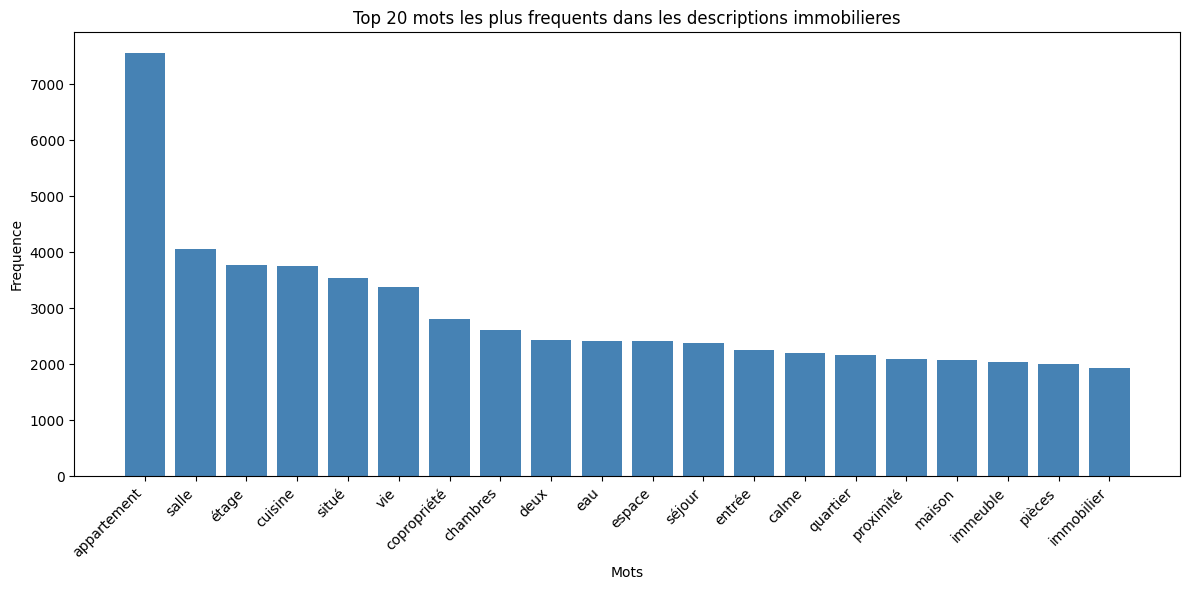

Graphique sauvegarde


In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top50_pd['mot'][:20], top50_pd['count'][:20], color='steelblue')
ax.set_xlabel('Mots')
ax.set_ylabel('Frequence')
ax.set_title('Top 20 mots les plus frequents dans les descriptions immobilieres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/barplot_nlp.png', dpi=100)
plt.show()
print('Graphique sauvegarde')

## Etape 7 — Interpretation des resultats NLP

Les mots les plus frequents revelent :
- **Attributs positifs** : calme, lumineux, vue, exclusivit
- **Equipements** : terrasse, balcon, parking, garage, cave
- **Localisation** : quartier, proche, commerces
- **Type de bien** : appartement, maison, studio, duplex

Ces 50 mots serviront de **features binaires** (presence/absence) pour le pipeline ML.

In [32]:
# Récupérer la liste des mots pour le notebook ML
TOP50_FEATURES = []
for row in top50_df.collect():
    TOP50_FEATURES.append(row['mot'])

print('Top 50 mots (à réutiliser dans le notebook 04) :')
print(TOP50_FEATURES)
spark.stop()

Top 50 mots (à réutiliser dans le notebook 04) :
['appartement', 'salle', 'étage', 'cuisine', 'situé', 'vie', 'copropriété', 'chambres', 'deux', 'eau', 'espace', 'séjour', 'entrée', 'calme', 'quartier', 'proximité', 'maison', 'immeuble', 'pièces', 'immobilier', 'pièce', 'résidence', 'chambre', 'lumineux', 'commerces', 'terrasse', 'rue', 'ascenseur', 'propose', 'ème', 'offre', 'très', 'équipée', 'exposé', 'place', 'jardin', 'charge', 'balcon', 'bordeaux', 'vue', 'pied', 'offrant', 'nantes', 'informations', 'vendeur', 'transports', 'cave', 'ouverte', 'site', 'classe']
